# 🛰️ DisasterDiff
## Explainable Building Damage Assessment from Pre- and Post-Disaster Satellite Imagery

---

### Exploratory Data Analysis

**Objective:**  
Analyse the xBD building-damage dataset, investigate class imbalance,
understand disaster-wise distributions, validate paired building crops,
and verify the leakage-safe train/validation/test split.

### Damage Categories

| Class | Description |
|---|---|
| 🟢 No Damage | Building remains largely intact |
| 🟡 Minor Damage | Limited visible structural damage |
| 🟠 Major Damage | Significant structural damage |
| 🔴 Destroyed | Building is severely damaged or destroyed |

---

**Dataset:** xBD / xView2  
**Usable building pairs:** 158,213  
**Disaster events:** 10  
**Source satellite tiles:** 2,240

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

DATA_ROOT = Path(r"D:\ML_Data\DisasterDiff")
METADATA_DIR = DATA_ROOT / "metadata"

FULL_DATA_PATH = METADATA_DIR / "building_pairs.csv"
TRAIN_PATH = METADATA_DIR / "train.csv"
VAL_PATH = METADATA_DIR / "validation.csv"
TEST_PATH = METADATA_DIR / "test.csv"

FIGURE_DIR = Path("../reports/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration loaded successfully.")

## 1. Dataset Overview

The original xBD satellite tiles were converted into paired building crops.

Each sample contains:

- a **pre-disaster** building image,
- a corresponding **post-disaster** building image,
- its damage severity label,
- disaster metadata,
- and the original source satellite tile ID.

Unclassified buildings and extremely small annotations were excluded during preprocessing.

In [ ]:
df = pd.read_csv(FULL_DATA_PATH)
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Full dataset:", df.shape)
print("Training set:", train_df.shape)
print("Validation set:", val_df.shape)
print("Test set:", test_df.shape)

In [ ]:
df.head()

## 2. Dataset Snapshot

Before visual exploration, let's summarize the size, diversity, and structure of the processed dataset.

In [6]:
from IPython.display import display, HTML

total_pairs = len(df)
total_tiles = df["tile_id"].nunique()
total_disasters = df["disaster"].nunique()
total_classes = df["label_name"].nunique()

cards_html = f"""
<div style="
    display:grid;
    grid-template-columns:repeat(4, 1fr);
    gap:16px;
    margin:20px 0;
">

    <div style="
        padding:22px;
        border-radius:16px;
        background:#E8F1FF;
        border:1px solid #C7DDFB;
        box-shadow:0 4px 12px rgba(0,0,0,0.15);
        text-align:center;
    ">
        <div style="
            font-size:30px;
            font-weight:700;
            color:#153E75;
        ">
            {total_pairs:,}
        </div>

        <div style="
            margin-top:8px;
            font-size:15px;
            font-weight:600;
            color:#2D3748;
        ">
            Building Pairs
        </div>
    </div>


    <div style="
        padding:22px;
        border-radius:16px;
        background:#EAFBF2;
        border:1px solid #C6F0D8;
        box-shadow:0 4px 12px rgba(0,0,0,0.15);
        text-align:center;
    ">
        <div style="
            font-size:30px;
            font-weight:700;
            color:#176B43;
        ">
            {total_tiles:,}
        </div>

        <div style="
            margin-top:8px;
            font-size:15px;
            font-weight:600;
            color:#2D3748;
        ">
            Source Tiles
        </div>
    </div>


    <div style="
        padding:22px;
        border-radius:16px;
        background:#FFF4E5;
        border:1px solid #F8D9A9;
        box-shadow:0 4px 12px rgba(0,0,0,0.15);
        text-align:center;
    ">
        <div style="
            font-size:30px;
            font-weight:700;
            color:#A45100;
        ">
            {total_disasters}
        </div>

        <div style="
            margin-top:8px;
            font-size:15px;
            font-weight:600;
            color:#2D3748;
        ">
            Disaster Events
        </div>
    </div>


    <div style="
        padding:22px;
        border-radius:16px;
        background:#F3ECFF;
        border:1px solid #DCCBFA;
        box-shadow:0 4px 12px rgba(0,0,0,0.15);
        text-align:center;
    ">
        <div style="
            font-size:30px;
            font-weight:700;
            color:#6542A6;
        ">
            {total_classes}
        </div>

        <div style="
            margin-top:8px;
            font-size:15px;
            font-weight:600;
            color:#2D3748;
        ">
            Damage Classes
        </div>
    </div>

</div>
"""

display(HTML(cards_html))

## 3. Dataset Split Overview

The processed dataset is divided into training, validation, and test sets.

To reduce spatial data leakage, the split was performed at the **source satellite tile level** rather than randomly splitting individual buildings.

In [7]:
split_summary = pd.DataFrame({
    "Split": [
        "Train",
        "Validation",
        "Test"
    ],
    "Samples": [
        len(train_df),
        len(val_df),
        len(test_df)
    ],
    "Source Tiles": [
        train_df["tile_id"].nunique(),
        val_df["tile_id"].nunique(),
        test_df["tile_id"].nunique()
    ],
    "Disasters": [
        train_df["disaster"].nunique(),
        val_df["disaster"].nunique(),
        test_df["disaster"].nunique()
    ]
})

split_summary["Percentage"] = (
    split_summary["Samples"]
    / len(df)
    * 100
).round(2)

display(
    split_summary.style
    .format({
        "Samples": "{:,}",
        "Source Tiles": "{:,}",
        "Percentage": "{:.2f}%"
    })
    .set_caption("Train / Validation / Test Summary")
)

,Split,Samples,Source Tiles,Disasters,Percentage
0,Train,"106,637","1,568",10,67.40%
1,Validation,"25,598",336,9,16.18%
2,Test,"25,978",336,10,16.42%


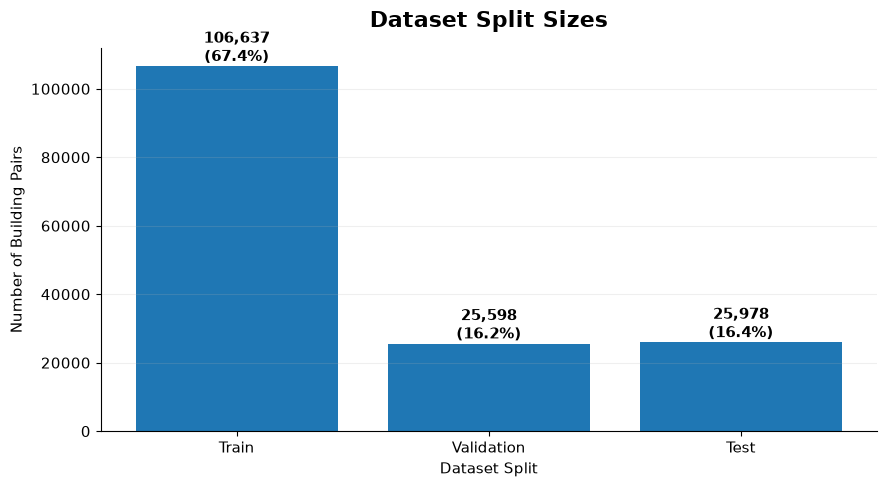

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    split_summary["Split"],
    split_summary["Samples"]
)

ax.set_title(
    "Dataset Split Sizes",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Number of Building Pairs")
ax.set_xlabel("Dataset Split")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.2
)

for bar, value, percentage in zip(
    bars,
    split_summary["Samples"],
    split_summary["Percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1500,
        f"{value:,}\n({percentage:.1f}%)",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "dataset_split_sizes.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

### Leakage Verification

Multiple buildings may originate from the same satellite tile.

If buildings from one tile appeared in both training and testing data, the model could learn location-specific visual patterns instead of general damage characteristics.

Therefore, every source tile is restricted to exactly one split.

In [9]:
train_tiles = set(train_df["tile_id"])
val_tiles = set(val_df["tile_id"])
test_tiles = set(test_df["tile_id"])

train_val_overlap = len(
    train_tiles.intersection(val_tiles)
)

train_test_overlap = len(
    train_tiles.intersection(test_tiles)
)

val_test_overlap = len(
    val_tiles.intersection(test_tiles)
)

print("Tile Leakage Check")
print("-" * 40)

print(
    "Train ↔ Validation overlap:",
    train_val_overlap
)

print(
    "Train ↔ Test overlap:",
    train_test_overlap
)

print(
    "Validation ↔ Test overlap:",
    val_test_overlap
)

Tile Leakage Check
----------------------------------------
Train ↔ Validation overlap: 0
Train ↔ Test overlap: 0
Validation ↔ Test overlap: 0


> ✅ **Leakage check passed:** No source satellite tile is shared between the training, validation, and test sets.

## 4. Data Quality Checks

Before training, the processed dataset is checked for missing metadata, duplicate rows, label consistency, and crop-shape consistency.

In [10]:
quality_report = pd.DataFrame({
    "Check": [
        "Missing metadata values",
        "Duplicate metadata rows",
        "Damage classes",
        "Disaster events",
        "Source tiles",
        "Non-square crops"
    ],

    "Result": [
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        int(df["label_name"].nunique()),
        int(df["disaster"].nunique()),
        int(df["tile_id"].nunique()),
        int(
            (
                df["crop_width"]
                != df["crop_height"]
            ).sum()
        )
    ]
})

display(
    quality_report.style
    .set_caption("Data Quality Summary")
)

,Check,Result
0,Missing metadata values,0
1,Duplicate metadata rows,0
2,Damage classes,4
3,Disaster events,10
4,Source tiles,2240
5,Non-square crops,0


In [11]:
sample_for_check = df.sample(
    n=1000,
    random_state=42
)

missing_before = 0
missing_after = 0

for _, row in sample_for_check.iterrows():

    if not Path(
        row["before_path"]
    ).exists():
        missing_before += 1

    if not Path(
        row["after_path"]
    ).exists():
        missing_after += 1


print("Image File Integrity Check")
print("-" * 40)

print(
    f"Pairs checked   : {len(sample_for_check):,}"
)

print(
    f"Missing before  : {missing_before}"
)

print(
    f"Missing after   : {missing_after}"
)

Image File Integrity Check
----------------------------------------
Pairs checked   : 1,000
Missing before  : 0
Missing after   : 0


> ✅ A reproducible random sample of 1,000 building pairs was checked and both images were successfully located.

## 5. Damage Class Distribution

A major challenge in this dataset is class imbalance.

Understanding the distribution of damage categories is essential before choosing the training loss and evaluation metrics.

In [12]:
class_order = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed"
]

class_counts = (
    df["label_name"]
    .value_counts()
    .reindex(class_order)
)

class_percentages = (
    class_counts
    / class_counts.sum()
    * 100
)

class_summary = pd.DataFrame({
    "Damage Class": class_order,
    "Samples": class_counts.values,
    "Percentage": class_percentages.values
})

display(
    class_summary.style
    .format({
        "Samples": "{:,}",
        "Percentage": "{:.2f}%"
    })
    .set_caption(
        "Overall Damage Class Distribution"
    )
)

,Damage Class,Samples,Percentage
0,no-damage,"116,242",73.47%
1,minor-damage,"14,905",9.42%
2,major-damage,"14,086",8.90%
3,destroyed,"12,980",8.20%


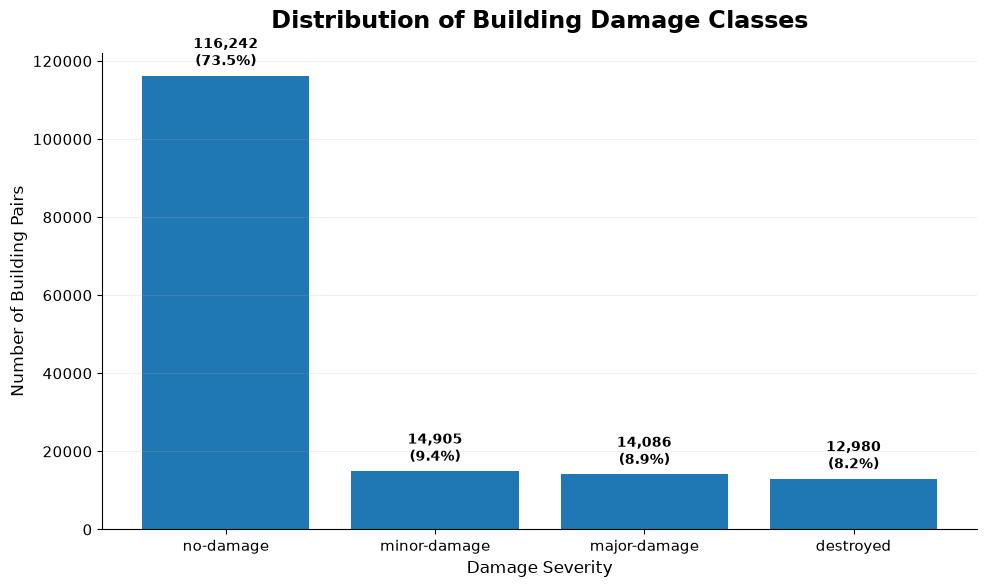

In [13]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.bar(
    class_summary["Damage Class"],
    class_summary["Samples"]
)

ax.set_title(
    "Distribution of Building Damage Classes",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Damage Severity",
    fontsize=12
)

ax.set_ylabel(
    "Number of Building Pairs",
    fontsize=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.2
)

for bar, count, percentage in zip(
    bars,
    class_summary["Samples"],
    class_summary["Percentage"]
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1500,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "class_distribution.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

### Key Observation

The dataset is strongly imbalanced.

- **No Damage** represents more than 70% of all samples.
- Minor, major, and destroyed buildings each account for less than 10%.

This imbalance could cause the model to favour the majority `no-damage` class.

### Modelling Decision

To handle this:

1. Weighted Cross-Entropy Loss will be evaluated.
2. Macro F1 will be used as a key metric.
3. Per-class precision and recall will be reported.
4. A confusion matrix will be analysed.

> Accuracy alone will not be sufficient for evaluating the model.

## 6. Disaster Event Distribution

The processed dataset contains buildings from multiple natural disasters.

Studying disaster-wise representation helps identify event-specific imbalance
and possible differences in geography, satellite conditions, and damage patterns.

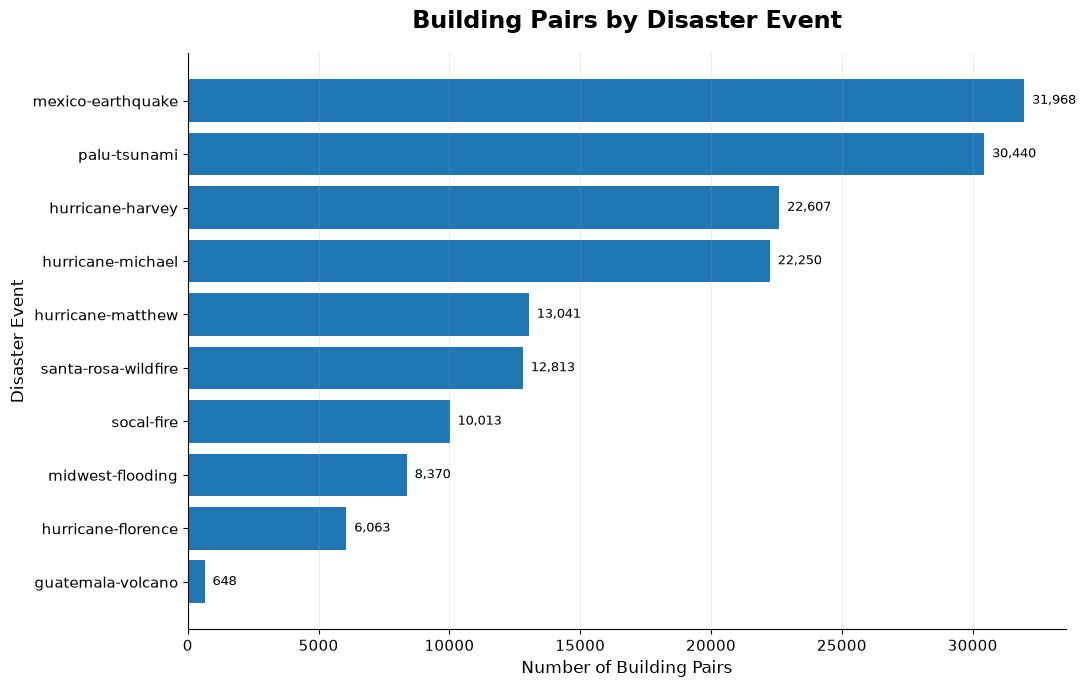

In [14]:
disaster_counts = (
    df["disaster"]
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(
    figsize=(11, 7)
)

bars = ax.barh(
    disaster_counts.index,
    disaster_counts.values
)

ax.set_title(
    "Building Pairs by Disaster Event",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Number of Building Pairs",
    fontsize=12
)

ax.set_ylabel(
    "Disaster Event",
    fontsize=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    alpha=0.2
)

for bar, value in zip(
    bars,
    disaster_counts.values
):

    ax.text(
        value + 300,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "disaster_distribution.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

In [15]:
disaster_class_table = pd.crosstab(
    df["disaster"],
    df["label_name"]
)

disaster_class_table = (
    disaster_class_table
    .reindex(columns=class_order)
)

display(
    disaster_class_table.style
    .format("{:,}")
    .set_caption(
        "Damage-Class Counts by Disaster"
    )
)

label_name,no-damage,minor-damage,major-damage,destroyed
disaster,,,,
guatemala-volcano,606,9,9,24
hurricane-florence,"4,645",130,"1,236",52
hurricane-harvey,"11,356","2,654","8,202",395
hurricane-matthew,"2,501","6,501","1,926","2,113"
hurricane-michael,"14,423","5,194","1,892",741
mexico-earthquake,"31,841",107,18,2
midwest-flooding,"8,030",149,118,73
palu-tsunami,"25,055",1,571,"4,813"
santa-rosa-wildfire,"9,214",78,63,"3,458"


In [16]:
disaster_class_percentage = (
    disaster_class_table
    .div(
        disaster_class_table.sum(axis=1),
        axis=0
    )
    * 100
)

display(
    disaster_class_percentage
    .round(2)
    .style
    .format("{:.2f}%")
    .set_caption(
        "Damage-Class Percentage by Disaster"
    )
)

label_name,no-damage,minor-damage,major-damage,destroyed
disaster,,,,
guatemala-volcano,93.52%,1.39%,1.39%,3.70%
hurricane-florence,76.61%,2.14%,20.39%,0.86%
hurricane-harvey,50.23%,11.74%,36.28%,1.75%
hurricane-matthew,19.18%,49.85%,14.77%,16.20%
hurricane-michael,64.82%,23.34%,8.50%,3.33%
mexico-earthquake,99.60%,0.33%,0.06%,0.01%
midwest-flooding,95.94%,1.78%,1.41%,0.87%
palu-tsunami,82.31%,0.00%,1.88%,15.81%
santa-rosa-wildfire,71.91%,0.61%,0.49%,26.99%


## 7. Before-and-After Building Pairs

DisasterDiff uses paired satellite imagery.

For every building, the same spatial region is extracted from:

- the **pre-disaster image**
- the **post-disaster image**

This allows the model to learn visual changes caused by the disaster rather
than relying only on the appearance of the damaged image.

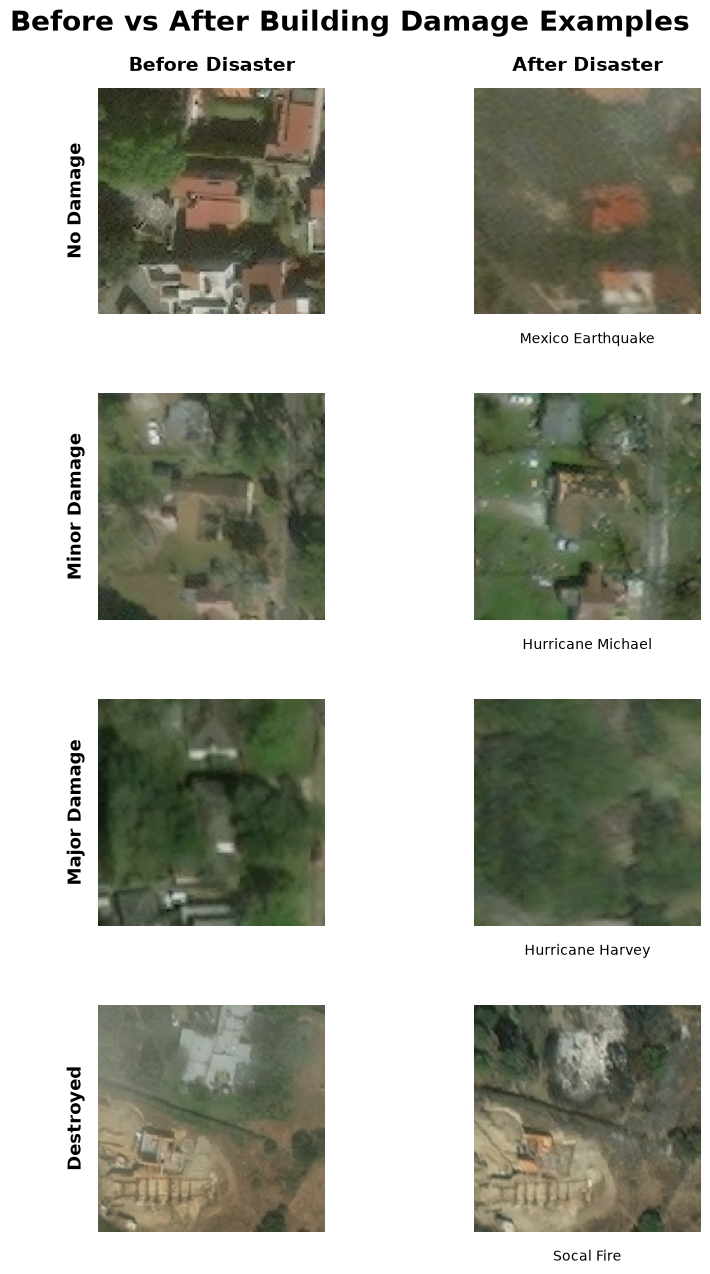

In [18]:
def show_damage_examples(
    dataframe,
    random_state=21
):
    classes = [
        "no-damage",
        "minor-damage",
        "major-damage",
        "destroyed"
    ]

    readable_names = {
        "no-damage": "No Damage",
        "minor-damage": "Minor Damage",
        "major-damage": "Major Damage",
        "destroyed": "Destroyed"
    }

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        nrows=4,
        ncols=2,
        figsize=(9, 13)
    )

    # Force a clean white presentation even in VS Code dark mode
    fig.patch.set_facecolor("white")

    fig.suptitle(
        "Before vs After Building Damage Examples",
        fontsize=20,
        fontweight="bold",
        y=0.98
    )

    # --------------------------------------------------------
    # Select one example from each class
    # --------------------------------------------------------

    for row_index, damage_class in enumerate(classes):

        class_data = dataframe[
            dataframe["label_name"] == damage_class
        ].copy()

        # Prefer reasonably sized crops for presentation
        class_data = class_data[
            class_data["crop_width"] >= 96
        ]

        sample = class_data.sample(
            n=1,
            random_state=random_state + row_index
        ).iloc[0]

        before_image = Image.open(
            sample["before_path"]
        ).convert("RGB")

        after_image = Image.open(
            sample["after_path"]
        ).convert("RGB")

        # ----------------------------------------------------
        # BEFORE
        # ----------------------------------------------------

        axes[row_index, 0].imshow(
            before_image
        )

        axes[row_index, 0].axis("off")

        # ----------------------------------------------------
        # AFTER
        # ----------------------------------------------------

        axes[row_index, 1].imshow(
            after_image
        )

        axes[row_index, 1].axis("off")

        # ----------------------------------------------------
        # Column headings
        # ----------------------------------------------------

        if row_index == 0:

            axes[row_index, 0].set_title(
                "Before Disaster",
                fontsize=14,
                fontweight="bold",
                pad=12
            )

            axes[row_index, 1].set_title(
                "After Disaster",
                fontsize=14,
                fontweight="bold",
                pad=12
            )

        # ----------------------------------------------------
        # Class label on the left
        # ----------------------------------------------------

        axes[row_index, 0].text(
            -0.10,
            0.5,
            readable_names[damage_class],
            transform=axes[row_index, 0].transAxes,
            rotation=90,
            va="center",
            ha="center",
            fontsize=13,
            fontweight="bold"
        )

        # ----------------------------------------------------
        # Disaster name under after image
        # ----------------------------------------------------

        disaster_name = (
            sample["disaster"]
            .replace("-", " ")
            .title()
        )

        axes[row_index, 1].text(
            0.5,
            -0.08,
            disaster_name,
            transform=axes[row_index, 1].transAxes,
            ha="center",
            va="top",
            fontsize=10
        )


    # --------------------------------------------------------
    # Layout
    # --------------------------------------------------------

    plt.subplots_adjust(
        left=0.16,
        right=0.95,
        top=0.92,
        bottom=0.04,
        hspace=0.35,
        wspace=0.12
    )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    plt.savefig(
        FIGURE_DIR / "before_after_gallery.png",
        dpi=250,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()


show_damage_examples(df)

## 8. Building Crop Characteristics

Buildings in xBD vary substantially in physical size and aspect ratio.

Directly resizing highly rectangular building crops to a fixed model input size
could distort their visual structure. Therefore, DisasterDiff generates a
**square context crop** around each building before resizing it for the neural
network.

This preserves the building's approximate geometry while retaining useful
surrounding context.

In [19]:
size_statistics = (
    df[
        [
            "building_width",
            "building_height",
            "crop_width",
            "crop_height"
        ]
    ]
    .describe()
    .round(2)
)

display(
    size_statistics.style
    .set_caption(
        "Building and Generated Crop Size Statistics"
    )
)

,building_width,building_height,crop_width,crop_height
count,158213.000000,158213.000000,158213.000000,158213.000000
mean,35.810000,35.200000,120.410000,120.410000
std,24.200000,23.130000,54.380000,54.380000
min,6.000000,6.000000,96.000000,96.000000
25%,20.410000,19.980000,96.000000,96.000000
50%,31.640000,31.070000,96.000000,96.000000
75%,45.140000,44.940000,126.000000,126.000000
max,1022.480000,709.010000,1024.000000,1024.000000


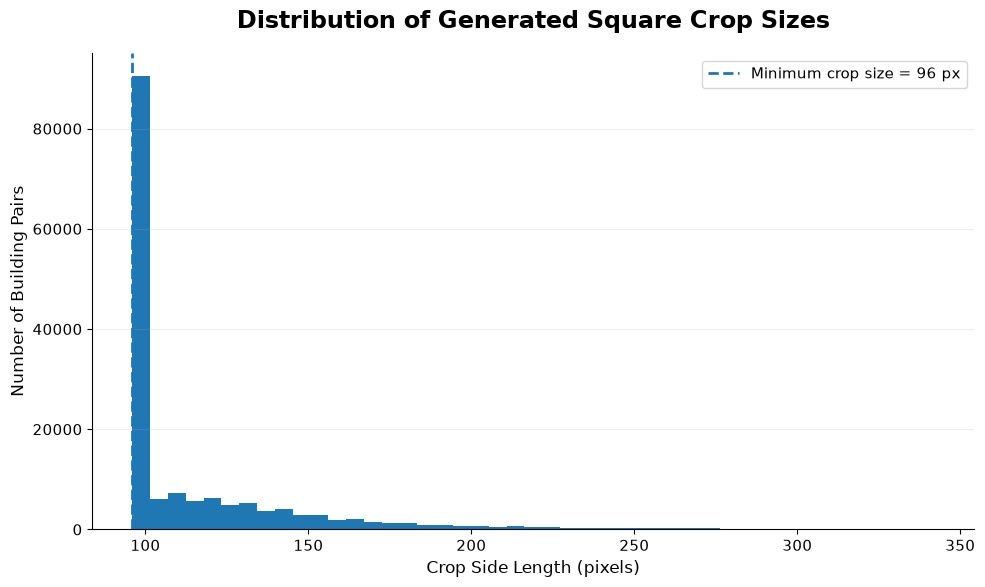

In [21]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

# Focus on the range containing most samples
upper_limit = df["crop_width"].quantile(0.99)

ax.hist(
    df.loc[
        df["crop_width"] <= upper_limit,
        "crop_width"
    ],
    bins=45
)

ax.axvline(
    96,
    linestyle="--",
    linewidth=2,
    label="Minimum crop size = 96 px"
)

ax.set_title(
    "Distribution of Generated Square Crop Sizes",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Crop Side Length (pixels)",
    fontsize=12
)

ax.set_ylabel(
    "Number of Building Pairs",
    fontsize=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.2
)

ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "crop_size_distribution.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

### Observation

A large proportion of crops occur at **96 × 96 pixels** because
`96` was deliberately chosen as the minimum crop size during preprocessing.

Small building polygons were therefore given additional surrounding context
instead of producing extremely tiny image patches.

A small number of larger buildings produce much larger crops, resulting in
a right-skewed distribution.

### Modelling Decision

All crops will subsequently be resized to **224 × 224 pixels**, matching
the input size used by the pretrained ResNet18 model.

In [22]:
crop_stats = pd.DataFrame({
    "Statistic": [
        "Minimum crop size",
        "Median crop size",
        "Mean crop size",
        "95th percentile",
        "99th percentile",
        "Maximum crop size",
        "Samples at minimum size"
    ],

    "Value": [
        df["crop_width"].min(),
        df["crop_width"].median(),
        round(df["crop_width"].mean(), 2),
        df["crop_width"].quantile(0.95),
        df["crop_width"].quantile(0.99),
        df["crop_width"].max(),
        (df["crop_width"] == 96).sum()
    ]
})

display(crop_stats)

,Statistic,Value
0,Minimum crop size,96.00
1,Median crop size,96.00
2,Mean crop size,120.41
3,95th percentile,203.00
4,99th percentile,342.00
5,Maximum crop size,1024.00
6,Samples at minimum size,84352.00


## 9. Damage-Class Distribution Across Dataset Splits

Since complete satellite tiles were kept together during splitting,
the exact class percentages are not identical across the training,
validation, and test sets.

However, every split contains all four damage categories.

In [23]:
def get_split_distribution(
    dataframe,
    split_name
):
    percentages = (
        dataframe["label_name"]
        .value_counts(normalize=True)
        .reindex(class_order)
        * 100
    )

    return pd.DataFrame({
        "Damage Class": percentages.index,
        "Percentage": percentages.values,
        "Split": split_name
    })


split_distribution_df = pd.concat(
    [
        get_split_distribution(
            train_df,
            "Train"
        ),

        get_split_distribution(
            val_df,
            "Validation"
        ),

        get_split_distribution(
            test_df,
            "Test"
        )
    ],
    ignore_index=True
)

pivot_distribution = (
    split_distribution_df
    .pivot(
        index="Damage Class",
        columns="Split",
        values="Percentage"
    )
)

display(
    pivot_distribution
    .round(2)
    .style
    .format("{:.2f}%")
    .set_caption(
        "Class Percentage Across Dataset Splits"
    )
)

Split,Test,Train,Validation
Damage Class,,,
destroyed,4.35%,9.87%,5.15%
major-damage,8.38%,8.96%,9.20%
minor-damage,9.65%,9.74%,7.87%
no-damage,77.62%,71.43%,77.78%


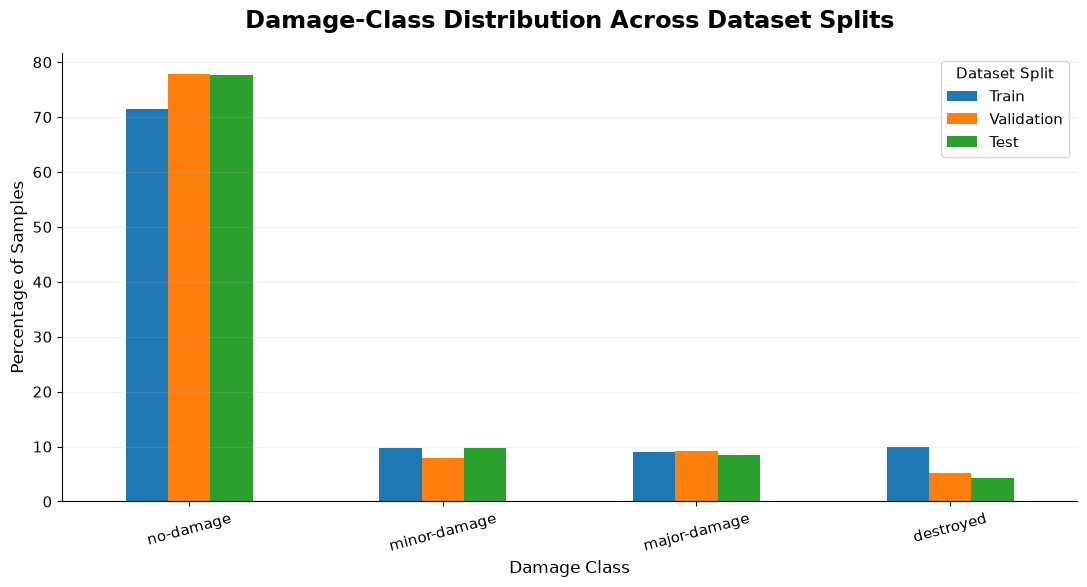

In [26]:
# Keep a logical damage-severity order
desired_class_order = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed"
]

pivot_distribution = pivot_distribution.reindex(
    desired_class_order
)

# Keep dataset splits in natural order
pivot_distribution = pivot_distribution[
    [
        "Train",
        "Validation",
        "Test"
    ]
]

ax = pivot_distribution.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title(
    "Damage-Class Distribution Across Dataset Splits",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Damage Class",
    fontsize=12
)

ax.set_ylabel(
    "Percentage of Samples",
    fontsize=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.2
)

plt.xticks(
    rotation=15
)

plt.legend(
    title="Dataset Split"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "split_class_distribution.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

### Observation

The validation and test sets contain a slightly larger proportion of
`no-damage` samples and fewer `destroyed` buildings than the training set.

This difference occurs because complete source satellite tiles were kept
together during splitting.

Preventing spatial data leakage was prioritised over forcing perfectly
identical class proportions across the three splits.